# Drzewa Decyzyjne

# 1 Wprowadzenie

Celem projektu jest zastosowanie drzew decyzyjnych do klasyfikacji typów gwiazd na podstawie ich właściwości fizycznych i termodynamicznych. Wykorzystano dataset Star Dataset udostępniony w repozytorium Kaggle, zawierający dane o różnych obiektach gwiezdnych.


# 2 Opis danych

## 2.1 Źródło danych
Dataset pochodzi z repozytorium Kaggle:
https://www.kaggle.com/datasets/deepu1109/star-dataset

Zbiór składa się z jednego pliku:
`6 class csv.csv` – 240 próbek ciał niebieskich reprezentujących 6 różnych klas gwiazd.

Po załadowaniu pliku otrzymano 240 próbek i 7 kolumn.

## 2.2 Cechy


## 2.3 Wczytanie i połączenie danych


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/6 class csv.csv")


star_mapping = {
    0: 'Brown Dwarf', 1: 'Red Dwarf', 2: 'White Dwarf', 
    3: 'Main Sequence', 4: 'Supergiant', 5: 'Hypergiant'
}
df['Star_name'] = df['Star type'].map(star_mapping)

print(f"Rozmiar datasetu: {df.shape}")


Rozmiar datasetu: (240, 8)


Dodana kolumna `Star_name` pozwala zachować czytelną informację o klasie obiektu, co znacząco ułatwia interpretację wykresów na etapie eksploracji danych.

# 3 Eksploracja danych

## 3.1 Podstawowe statystyki


In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.head())


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    str    
 6   Spectral Class          240 non-null    str    
 7   Star_name               240 non-null    str    
dtypes: float64(3), int64(2), str(3)
memory usage: 15.1 KB
None
       Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
count       240.000000        240.000000    240.000000   
mean      10497.462500     107188.361635    237.157781   
std        9552.425037     179432.244940    517.155763   
min        1939.000000          0.000080      0.008400   
25%        3344.250000 

Zbiór danych zawiera 240 próbek bez żadnych brakujących wartości – nie jest wymagane żadne uzupełnianie danych (imputacja). Cechy fizyczne mają typ numeryczny (`int64` i `float64`), natomiast kolumny `Star color` oraz `Spectral Class` są typu kategorycznego (`object`) i w kolejnych etapach będą wymagały modyfikacji.

## 3.2 Rozkład zmiennej docelowej


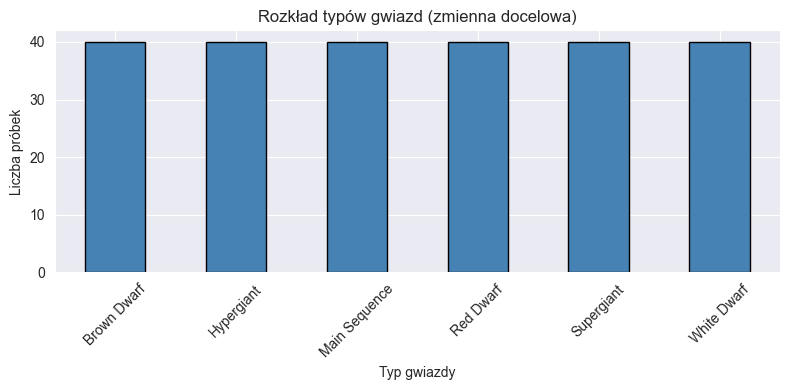

In [3]:
plt.figure(figsize=(8, 4))
df['Star_name'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Rozkład typów gwiazd (zmienna docelowa)')
plt.xlabel('Typ gwiazdy')
plt.ylabel('Liczba próbek')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Rysunek 1: Rozkład typów gwiazd w zbiorze danych

Rozkład zmiennej `Star type` jest równomierny

Tabela 2: Liczba próbek per klasa




## 3.3 Korelacja cech


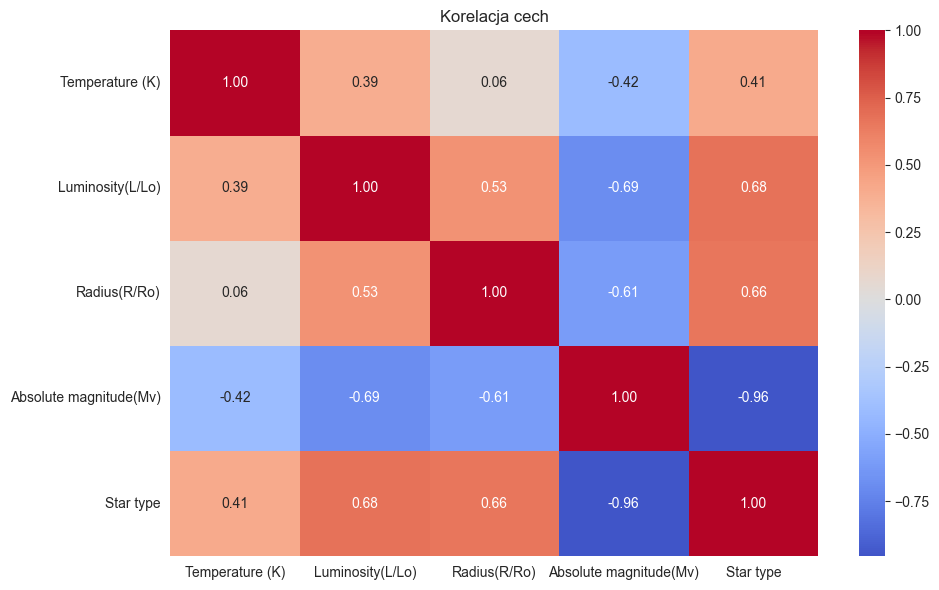

In [4]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Star type'])
numeric_cols['Star type'] = df['Star type']

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Korelacja cech')
plt.tight_layout()
plt.show()


Rysunek 2: Macierz korelacji cech

Najważniejsze obserwacje z macierzy korelacji:
1. `Absolute magnitude(Mv)` ma najwyższą ujemną korelację ze `Star type` (-0.96) – im wyższa (bardziej dodatnia) wartość magnitudo (ciemniejszy obiekt), tym niższa klasa gwiazdy,
2. `Luminosity(L/Lo)` oraz `Radius(R/Ro)` mają wysoką dodatnią korelację ze `Star type` (+0.68 i +0.66) – większe i jaśniejsze gwiazdy należą do wyższych klas (np. Nadolbrzymy, Hiperolbrzymy),
3. `Temperature (K)` wykazuje słabszą, ale zauważalną korelację z klasą docelową (+0.41).

